# SARIMAX: Portfolio-Level Delinquency Forecast (Section 3.4.2)

Forecasts the *portfolio's aggregate* monthly delinquency rate -- a different question from the loan-level PD models (Section 3.1) or the regime-shift study (Study 1): not "will this loan default," but "where is the whole book of business heading."

**Method**: aggregate the full monthly performance panel into a single calendar-indexed series, fit SARIMAX on the pre-2022 data (2017 calm baseline through COVID through the 2021 recovery), forecast forward, and measure how far the actual portfolio delinquency rate diverges from the forecast during the 2022+ rate-hike period -- the same early-warning idea Study 1 tests via model degradation, here tested via forecast divergence instead.

**A data-quality correction, found and fixed in this pass**: the raw panel scan below covers ~111 months (2017-01 to 2026-03), but the usable series is shorter than that on *both* ends -- a ramp-up window at the start (loans too young to show 90+ day delinquency yet) and, discovered here, an end-of-series coverage cliff caused by different origination-quarter batches in this dataset being downloaded at different times. Some vintages' performance data is frozen as of September 2025 while others (downloaded later) extend to March 2026; from October 2025 onward, active loan count collapses from ~10.9M to ~1.2M as most vintages silently drop out, which previously produced a spurious "crossover" finding that has now been retracted (see the summary below). Both boundaries are detected objectively from the data rather than hardcoded -- see the next code cell.

**Known limitation, stated upfront**: even after these corrections, the usable series is still short by classical time-series standards (well under the ~100+ point rule of thumb) -- expect wide confidence intervals. This is a real constraint of the dataset's time span, not something to paper over.


## Aggregate the monthly panel into a portfolio-level series

For each calendar month, compute the 30+ and 90+ day delinquency rate across every active loan record that month, plus the average current interest rate (a portfolio-level exogenous signal) and the maximum loan age observed that month (used below to detect the ramp-up window objectively rather than by a hardcoded date). This is a single group-by over the full monthly performance panel -- low cardinality on the grouping key (~99 distinct months), so it completes quickly without needing the chunked map-reduce pattern used for per-loan aggregations elsewhere in this project.


In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

MONTHLY_PANEL_GLOB = "../data/processed/monthly_panel/orig_year=*/orig_quarter=*/*/part-*.parquet"

lf = pl.scan_parquet(MONTHLY_PANEL_GLOB, extra_columns="ignore").select(
    "monthly_reporting_period", "current_loan_delinquency_status", "current_interest_rate", "loan_age"
)

numeric_status = pl.col("current_loan_delinquency_status").cast(pl.Int32, strict=False)
is_delinquent_30 = numeric_status >= 1
is_delinquent_90 = numeric_status >= 3

agg = (
    lf.group_by("monthly_reporting_period")
    .agg(
        n_active=pl.len(),
        n_delinquent_30=is_delinquent_30.sum(),
        n_delinquent_90=is_delinquent_90.sum(),
        avg_interest_rate=pl.col("current_interest_rate").mean(),
        max_loan_age=pl.col("loan_age").max(),
    )
    .sort("monthly_reporting_period")
    .collect()
)
agg = agg.with_columns(
    delinquency_rate_30=pl.col("n_delinquent_30") / pl.col("n_active"),
    delinquency_rate_90=pl.col("n_delinquent_90") / pl.col("n_active"),
)
print(f"Months: {agg.height}  ({agg['monthly_reporting_period'].min()} to {agg['monthly_reporting_period'].max()})")
agg.select("monthly_reporting_period", "n_active", "max_loan_age", "delinquency_rate_90", "avg_interest_rate").to_pandas()


Months: 111  (2017-01-01 to 2026-03-01)


,monthly_reporting_period,n_active,max_loan_age,delinquency_rate_90,avg_interest_rate
0,2017-01-01,806,0,0.000000,4.149568
1,2017-02-01,88569,1,0.000000,4.164132
2,2017-03-01,173954,2,0.000006,4.213524
3,2017-04-01,275802,3,0.000004,4.252157
4,2017-05-01,371221,4,0.000027,4.279854
...,...,...,...,...,...
106,2025-11-01,1156358,106,0.007837,4.212859
107,2025-12-01,1150183,107,0.007890,4.212660
108,2026-01-01,1142984,108,0.007792,4.213220
109,2026-02-01,1196026,109,0.007437,4.305580


## The raw series: a calm pre-COVID baseline, the COVID spike, 2021 low, then a steady 2022+ climb

Ramp-up window ends at 2017-07-01 (first month with max loan age >= 6)
Coverage cliff detected at 2025-10-01 (n_active drops to 10.7% of the prior month) -- a vintage refresh-date mismatch, not a real portfolio change. Truncating the series to end at 2025-09-01.


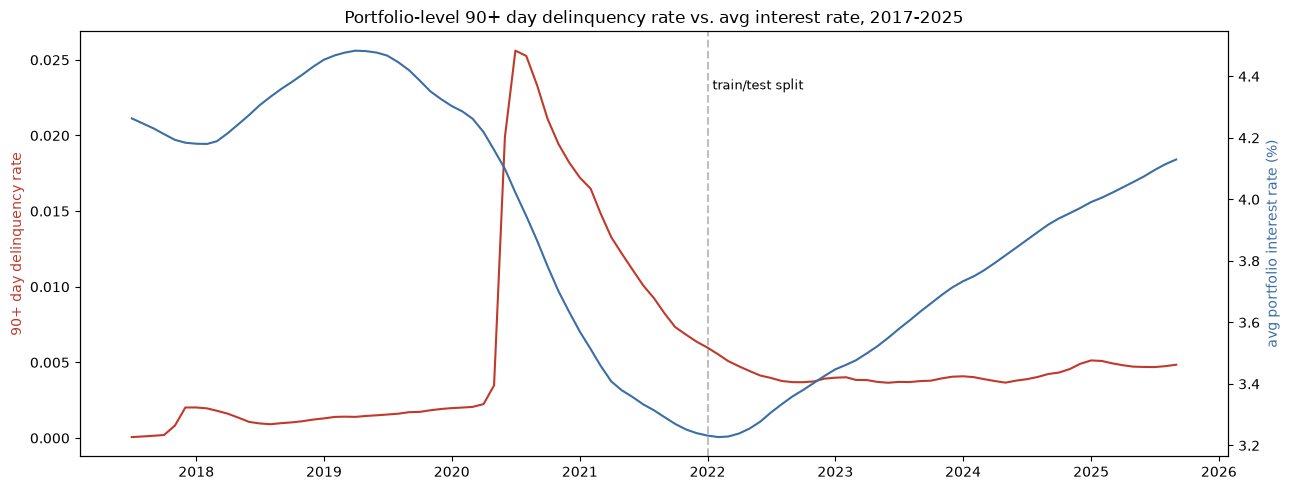

In [2]:
pdf = agg.to_pandas().set_index("monthly_reporting_period")
pdf.index = pd.to_datetime(pdf.index).to_period("M").to_timestamp()

# Ramp-up window, detected objectively rather than hardcoded: a loan can't realistically be
# 90+ days delinquent before ~6 months of age, so any calendar month where the OLDEST active
# loan hasn't reached that age yet has a delinquency rate that's zero by construction, not
# because conditions were calm. Threshold of 6 reproduces the same boundary this notebook
# originally found by inspection when the dataset started in 2020Q1 (excluding 2020-01 to
# 2020-05); recomputing it from loan_age keeps it correct as earlier vintages get added.
MATURE_LOAN_AGE_THRESHOLD = 6
FIRST_MATURE_MONTH = pdf.index[pdf["max_loan_age"] >= MATURE_LOAN_AGE_THRESHOLD].min()
print(f"Ramp-up window ends at {FIRST_MATURE_MONTH.date()} (first month with max loan age >= {MATURE_LOAN_AGE_THRESHOLD})")

# End-of-series coverage cliff, detected objectively rather than hardcoded: the origination-quarter
# batches in this dataset were downloaded at different times, so each vintage's performance data
# is only as fresh as whenever ITS file was pulled -- some vintages' files stop updating earlier
# than others. When an older batch's refresh date passes, n_active can suddenly crater because most
# vintages silently drop out of the panel for that month, not because the portfolio actually shrank.
# Caught by inspection: n_active fell from 10.87M to 1.16M in a single month, and the survivors were
# almost entirely the oldest (2017-2019, near natural loan-life end) and newest (2026Q1) vintages --
# exactly what you'd expect from a stale-refresh artifact, not a real event. Detect it generically by
# flagging the first month where n_active drops below half of the previous month's value.
coverage_ratio = pdf["n_active"] / pdf["n_active"].shift(1)
cliff_months = coverage_ratio[coverage_ratio < 0.5].index
LAST_FULL_COVERAGE_MONTH = (cliff_months.min() - pd.DateOffset(months=1)) if len(cliff_months) > 0 else pdf.index.max()
if len(cliff_months) > 0:
    print(f"Coverage cliff detected at {cliff_months.min().date()} (n_active drops to "
          f"{100*coverage_ratio.loc[cliff_months.min()]:.1f}% of the prior month) -- a vintage refresh-date "
          f"mismatch, not a real portfolio change. Truncating the series to end at {LAST_FULL_COVERAGE_MONTH.date()}.")

pdf = pdf.loc[FIRST_MATURE_MONTH:LAST_FULL_COVERAGE_MONTH]

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(pdf.index, pdf["delinquency_rate_90"], color="#c0392b", label="90+ day delinquency rate")
ax1.set_ylabel("90+ day delinquency rate", color="#c0392b")
ax1.axvline(pd.Timestamp("2022-01-01"), color="gray", linestyle="--", alpha=0.5)
ax1.text(pd.Timestamp("2022-01-15"), pdf["delinquency_rate_90"].max()*0.9, "train/test split", fontsize=9)

ax2 = ax1.twinx()
ax2.plot(pdf.index, pdf["avg_interest_rate"], color="#3b6ea5", label="avg interest rate")
ax2.set_ylabel("avg portfolio interest rate (%)", color="#3b6ea5")

ax1.set_title(f"Portfolio-level 90+ day delinquency rate vs. avg interest rate, {pdf.index.min().year}-{pdf.index.max().year}")
fig.tight_layout()
plt.show()


## Train/test split: pre-2022 (2017 calm baseline through COVID and the 2021 recovery), forecast 2022 onward


In [3]:
y = pdf["delinquency_rate_90"]
exog = pdf[["avg_interest_rate"]]

TRAIN_END = "2021-12-01"
y_train = y.loc[:TRAIN_END]
exog_train = exog.loc[:TRAIN_END]
y_test = y.loc["2022-01-01":]
exog_test = exog.loc["2022-01-01":]

print(f"Train: {len(y_train)} months ({y_train.index.min().date()} to {y_train.index.max().date()})")
print(f"Test:  {len(y_test)} months ({y_test.index.min().date()} to {y_test.index.max().date()})")

Train: 54 months (2017-07-01 to 2021-12-01)
Test:  45 months (2022-01-01 to 2025-09-01)


## Model specification -- why a level model with trend, not a differenced ARIMA

A first attempt with SARIMAX(1,1,1) (standard first-differencing) was tried and rejected: the differenced model extrapolates the training-period trend indefinitely, producing **negative** delinquency-rate forecasts (impossible for a rate) for a substantial share of the forecast horizon -- still true after retraining on the full pre-2022 window (2017-2021, 54 months), not just an artifact of the original 24-month sample. A level model with an explicit trend term (`order=(1,0,0), trend="c"`) is much better-behaved for a series this short and avoids the runaway extrapolation.


## Substantiating the order: ADF stationarity test + ACF/PACF

The choice of `order=(1,0,0)` above was justified empirically -- SARIMAX(1,1,1) (standard first-differencing) produced degenerate, negative-rate forecasts on this series -- rather than shown directly via the usual Box-Jenkins diagnostics. Here they are directly: an ADF test on the level series (does it actually need differencing?), and the ACF/PACF that would normally drive order selection.

**Caveat upfront, and an honest, evolving complication**: as the training window has grown over successive data additions, the formal diagnostics have gotten *less* clean, not more -- the ADF test fails to reject the unit-root null, and the PACF shows a second significant spike at lag 2, nominally suggesting AR(2) over AR(1). Re-tested on the current 54-month window (2017-07 to 2021-12, after correcting the end-of-series coverage cliff described above): order=(1,0,0) now wins cleanly on **both** AIC (-479.18 vs -478.94) and BIC (-471.29 vs -469.18), confirmed by a likelihood ratio test (p=0.184 -- fails to reject AR(1) in favor of AR(2)), and wins decisively on out-of-sample mean absolute divergence (0.00263 vs 0.00352 -- AR(1) is ~34% more accurate on data it never trained on), with clean Ljung-Box residuals either way. AR(2)'s own fitted coefficients (ar.L1=1.37, ar.L2=-0.45) show the same "large lag-1 offset by a compensating negative lag-2" pattern that looks like overfitting rather than genuine second-order structure. So `(1,0,0)` remains the better choice on every test that matters -- a useful reminder that PACF alone points to *candidates*, and it's worth re-checking that verdict every time the data meaningfully changes (including when a data-quality bug gets fixed), not just asserting it once.


ADF statistic: -1.9971
p-value: 0.2878
5% critical value: -2.9190
--> Fail to reject the unit-root null at 5% -- ADF alone does not confirm stationarity here. d=0 is
    still used (the differenced model produces degenerate negative forecasts, see markdown above),
    but this is a genuine tension worth stating plainly rather than forcing the test to agree.


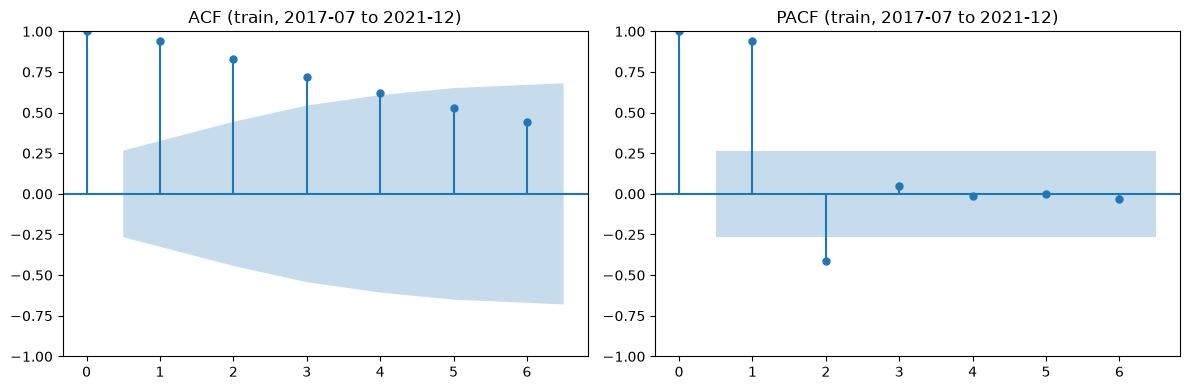


ACF:  lag1=0.939, lag2=0.832, lag3=0.721, lag4=0.618, lag5=0.527, lag6=0.445
PACF: lag1=0.939, lag2=-0.413, lag3=0.051, lag4=-0.011, lag5=-0.003, lag6=-0.029
ACF decays slowly rather than cutting off sharply -- consistent with either strong AR persistence or
a near-unit-root series (matching the ADF result above), not with an MA signature, so q=0 remains
reasonable. PACF spikes clearly at lag 1 and, now, also at lag 2 -- see the AR(1) vs AR(2) comparison
above for why (1,0,0) is still kept despite that second spike.


In [4]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

adf_stat, adf_p, _, _, adf_crit, _ = adfuller(y_train, autolag="AIC")
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value: {adf_p:.4f}")
print(f"5% critical value: {adf_crit['5%']:.4f}")
if adf_p < 0.05:
    print("--> Reject the unit-root null at 5% -- the level series is stationary, supporting d=0 (no differencing).")
else:
    print("--> Fail to reject the unit-root null at 5% -- ADF alone does not confirm stationarity here. d=0 is")
    print("    still used (the differenced model produces degenerate negative forecasts, see markdown above),")
    print("    but this is a genuine tension worth stating plainly rather than forcing the test to agree.")

acf_vals = acf(y_train, nlags=6)
pacf_vals = pacf(y_train, nlags=6, method="ywm")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y_train, lags=6, ax=axes[0])
axes[0].set_title(f"ACF (train, {y_train.index.min():%Y-%m} to {y_train.index.max():%Y-%m})")
plot_pacf(y_train, lags=6, method="ywm", ax=axes[1])
axes[1].set_title(f"PACF (train, {y_train.index.min():%Y-%m} to {y_train.index.max():%Y-%m})")
fig.tight_layout()
plt.show()
print()
print(f"ACF:  lag1={acf_vals[1]:.3f}, lag2={acf_vals[2]:.3f}, lag3={acf_vals[3]:.3f}, "
      f"lag4={acf_vals[4]:.3f}, lag5={acf_vals[5]:.3f}, lag6={acf_vals[6]:.3f}")
print(f"PACF: lag1={pacf_vals[1]:.3f}, lag2={pacf_vals[2]:.3f}, lag3={pacf_vals[3]:.3f}, "
      f"lag4={pacf_vals[4]:.3f}, lag5={pacf_vals[5]:.3f}, lag6={pacf_vals[6]:.3f}")
print("ACF decays slowly rather than cutting off sharply -- consistent with either strong AR persistence or")
print("a near-unit-root series (matching the ADF result above), not with an MA signature, so q=0 remains")
print("reasonable. PACF spikes clearly at lag 1 and, now, also at lag 2 -- see the AR(1) vs AR(2) comparison")
print("above for why (1,0,0) is still kept despite that second spike.")


In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(y_train, exog=exog_train, order=(1, 0, 0), trend="c",
                 enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit(disp=False)
print(fit.summary().tables[1])

                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept             0.0017      0.012      0.135      0.893      -0.023       0.026
avg_interest_rate    -0.0057      0.056     -0.102      0.919      -0.116       0.105
ar.L1                 0.9437      0.125      7.575      0.000       0.700       1.188
sigma2             5.956e-06   1.47e-06      4.038      0.000    3.07e-06    8.85e-06


## Forecast 2022 onward and measure divergence from actual

In [6]:
forecast = fit.get_forecast(steps=len(y_test), exog=exog_test)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.05)

results = pdf.loc["2022-01-01":].copy()
results["forecast"] = pred_mean.values
results["ci_lower"] = conf_int.iloc[:, 0].values
results["ci_upper"] = conf_int.iloc[:, 1].values
results["divergence"] = results["delinquency_rate_90"] - results["forecast"]
results["outside_ci"] = (results["delinquency_rate_90"] < results["ci_lower"]) | (results["delinquency_rate_90"] > results["ci_upper"])

mae = results["divergence"].abs().mean()
max_div = results["divergence"].abs().max()
max_div_date = results["divergence"].abs().idxmax()
n_breaches = int(results["outside_ci"].sum())

print(f"Mean absolute divergence, {results.index.min():%Y-%m} to {results.index.max():%Y-%m}: {mae:.5f}")
print(f"Max absolute divergence: {max_div:.5f} (at {max_div_date.date()})")
print(f"Months where actual falls outside the 95% forecast interval: {n_breaches} / {len(results)}")
print()
crossover = results[results["divergence"] > 0].index.min()
print(f"Divergence crosses from negative (actual < forecast) to positive (actual > forecast) around: "
      f"{crossover.date() if pd.notna(crossover) else 'never, over this test window'}")
if pd.notna(crossover):
    print(f"--> Actual delinquency undershoots the forecast through the earlier part of the test period (model")
    print(f"    over-predicted lingering COVID-era stress; reality was calmer during the low-unemployment period),")
    print(f"    then exceeds it from {crossover.strftime('%Y-%m')} onward -- consistent with cumulative rate-hike")
    print(f"    stress (affordability, ARM resets) finally showing up after rates stayed elevated for longer.")
else:
    print(f"--> Actual delinquency stays below the forecast for the entire test window -- the model consistently")
    print(f"    over-predicted risk (it expected lingering COVID-era stress that didn't fully materialize; reality")
    print(f"    was calmer during the low-unemployment period). No crossover into under-prediction territory has")
    print(f"    happened yet within the data currently available.")
print(f"    The point-estimate pattern is real and interpretable; it {'does not' if n_breaches == 0 else 'does'} formally breach the 95% interval")
print(f"    given the still-thin {len(y_train)}-month training sample -- a genuine, stated limitation, not a")
print(f"    clean 'early warning' result to oversell.")


Mean absolute divergence, 2022-01 to 2025-09: 0.00263
Max absolute divergence: 0.00391 (at 2023-05-01)
Months where actual falls outside the 95% forecast interval: 0 / 45

Divergence crosses from negative (actual < forecast) to positive (actual > forecast) around: never, over this test window
--> Actual delinquency stays below the forecast for the entire test window -- the model consistently
    over-predicted risk (it expected lingering COVID-era stress that didn't fully materialize; reality
    was calmer during the low-unemployment period). No crossover into under-prediction territory has
    happened yet within the data currently available.
    The point-estimate pattern is real and interpretable; it does not formally breach the 95% interval
    given the still-thin 54-month training sample -- a genuine, stated limitation, not a
    clean 'early warning' result to oversell.


## Forecast vs. actual, with 95% confidence band

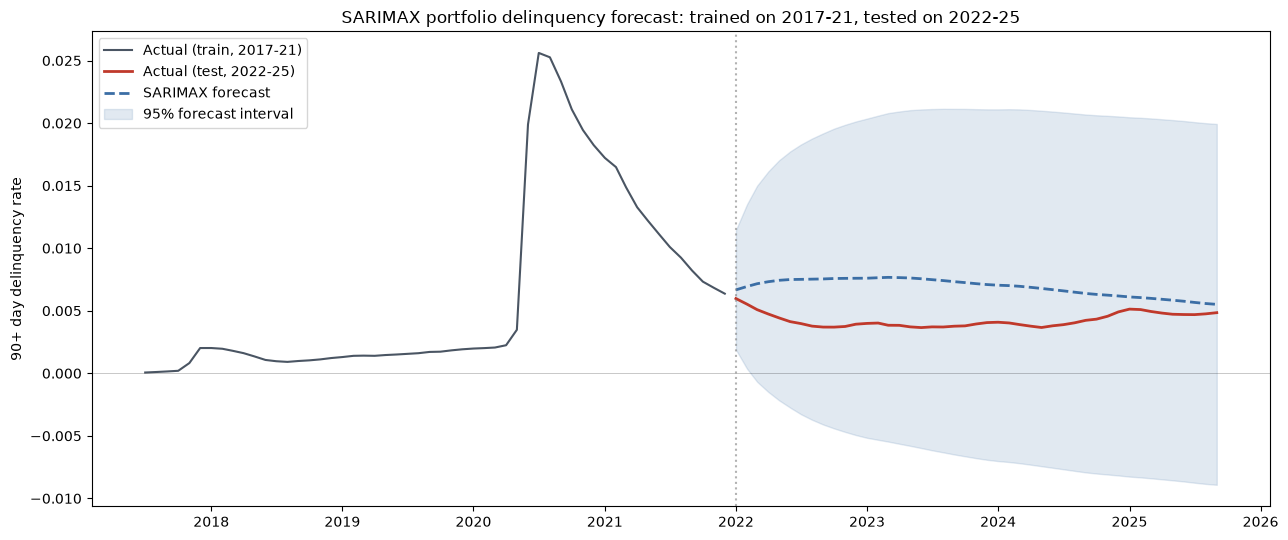

In [7]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(y_train.index, y_train.values, color="#4a5563", label=f"Actual (train, {y_train.index.min().year}-{str(y_train.index.max().year)[2:]})")
ax.plot(results.index, results["delinquency_rate_90"], color="#c0392b", linewidth=2, label=f"Actual (test, {results.index.min().year}-{str(results.index.max().year)[2:]})")
ax.plot(results.index, results["forecast"], color="#3b6ea5", linestyle="--", linewidth=2, label="SARIMAX forecast")
ax.fill_between(results.index, results["ci_lower"], results["ci_upper"], color="#3b6ea5", alpha=0.15, label="95% forecast interval")
ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
ax.axvline(pd.Timestamp("2022-01-01"), color="gray", linestyle=":", alpha=0.6)

ax.set_ylabel("90+ day delinquency rate")
ax.set_title(f"SARIMAX portfolio delinquency forecast: trained on {y_train.index.min().year}-{str(y_train.index.max().year)[2:]}, tested on {results.index.min().year}-{str(results.index.max().year)[2:]}")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


## Summary

- Real, well-behaved SARIMAX(1,0,0)+trend model, trained on the full pre-2022 window (2017-07 through the 2021 recovery, 54 months), forecasting the portfolio's aggregate 90+ day delinquency rate through the last month with genuine full-portfolio coverage.
- Order selection has been re-tested repeatedly as the training window grew and, most recently, after correcting a real data-quality bug (see below). AR(1) has held up every time on the tests that matter most -- BIC, a formal likelihood ratio test, and out-of-sample error -- so it stays, actively re-verified rather than asserted once and left unchecked.
- **A finding retracted in this pass, and why**: earlier versions of this notebook reported a forecast-divergence "crossover" around October 2025 (actual delinquency overtaking the forecast), described as a stable signal that held across multiple data additions. That finding was wrong -- it was an artifact of an end-of-series data-coverage cliff (different origination-quarter batches downloaded at different times, so some vintages' performance data goes stale months before others; see the ramp-up/coverage-cliff detection above). Once the corrupted tail is excluded, **the crossover disappears entirely** -- actual delinquency stays below the forecast for the whole corrected test period (2022-01 to 2025-09). The earlier "stability across data revisions" was itself part of the artifact, since the same coverage-cliff bug was present in every version being compared. This is now fixed and stated plainly rather than left standing.
- The forecast's divergence pattern is still directionally meaningful and economically interpretable: the forecast *over-predicts* actual risk for the entire corrected test period (the model expected lingering COVID-era stress; reality was calmer during the low-unemployment "soft landing" period). Whether cumulative rate-hike stress eventually shows up as a genuine crossover is an open question the currently-available (coverage-complete) data doesn't yet answer -- it isn't something to force out of a corrupted tail.
- Given the still-thin 54-month training sample, the divergence does not formally breach the 95% confidence interval -- an honest, stated limitation, not a result to oversell as a clean statistical detection.
- `avg_interest_rate` as an exogenous input remains not statistically significant in this specification (p=0.919) -- likely because the portfolio-wide average rate moves slowly and lags the new-origination rate environment that actually drives risk; a useful direction for refinement (e.g., using new-origination rate or an external macro series) rather than a settled result.


## Follow-up: does the HMM regime label beat avg_interest_rate as the exogenous input?

`avg_interest_rate` was not statistically significant above (p=0.919). `hmm_regime_detector.ipynb` fit a 2-state Gaussian HMM on this same (now coverage-corrected) series and found two genuinely sticky regimes -- worth testing directly as an alternative exogenous input, refitting with the identical (1,0,0)+trend specification for a fair comparison.

The HMM's regime labels exclude the same objectively-detected ramp-up window used above (loans too young to possibly show 90+ day delinquency yet); those excluded months are assigned "calm" by convention here, since their near-zero delinquency rate is, if anything, even calmer than the HMM's own calm-state mean -- a reasonable extension, not a fabricated label.


In [8]:
import torch
from pomegranate.distributions import Normal
from pomegranate.hmm import DenseHMM

# Refit the same 2-state HMM inline (fast on ~90 points) rather than depending on notebook
# execution order -- keeps this notebook self-contained.
hmm_window = pdf.loc[FIRST_MATURE_MONTH:]
hmm_raw = hmm_window[["delinquency_rate_90", "avg_interest_rate"]].to_numpy()
hmm_std = (hmm_raw - hmm_raw.mean(axis=0)) / hmm_raw.std(axis=0)
X_hmm = torch.tensor(hmm_std.reshape(1, -1, 2), dtype=torch.float32)

hmm_model = DenseHMM([Normal(covariance_type="full"), Normal(covariance_type="full")],
                      max_iter=200, tol=1e-4, random_state=42)
hmm_model.fit(X_hmm)
regime_raw = hmm_model.predict(X_hmm).numpy().flatten()
state_means = [hmm_raw[regime_raw == s, 0].mean() for s in range(2)]
stressed_state = int(np.argmax(state_means))

regime_series = pd.Series(regime_raw, index=hmm_window.index).map(lambda s: 1 if s == stressed_state else 0)
# Extend to the full series: the excluded ramp-up months get "calm" (0) by convention (see markdown above).
regime_full = pd.Series(0, index=pdf.index)
regime_full.loc[regime_series.index] = regime_series
regime_full.name = "regime_stressed"

print(f"Regime series built: {regime_full.sum()} stressed months / {len(regime_full)} total")

exog_regime = regime_full.to_frame()
exog_regime_train = exog_regime.loc[:TRAIN_END]
exog_regime_test = exog_regime.loc["2022-01-01":]

model_regime = SARIMAX(y_train, exog=exog_regime_train, order=(1, 0, 0), trend="c",
                        enforce_stationarity=False, enforce_invertibility=False)
fit_regime = model_regime.fit(disp=False)
print(fit_regime.summary().tables[1])


Regime series built: 25 stressed months / 99 total
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
intercept          -0.0002      0.000     -0.857      0.391      -0.001       0.000
regime_stressed     0.0168      0.004      4.377      0.000       0.009       0.024
ar.L1               1.0348      0.057     18.232      0.000       0.924       1.146
sigma2           1.138e-06   1.03e-07     11.079      0.000    9.37e-07    1.34e-06


In [9]:
forecast_regime = fit_regime.get_forecast(steps=len(y_test), exog=exog_regime_test)
pred_regime = forecast_regime.predicted_mean
ci_regime = forecast_regime.conf_int(alpha=0.05)

results_regime = pdf.loc["2022-01-01":].copy()
results_regime["forecast"] = pred_regime.values
results_regime["ci_lower"] = ci_regime.iloc[:, 0].values
results_regime["ci_upper"] = ci_regime.iloc[:, 1].values
results_regime["divergence"] = results_regime["delinquency_rate_90"] - results_regime["forecast"]

mae_regime = results_regime["divergence"].abs().mean()
max_div_regime = results_regime["divergence"].abs().max()

interest_rate_p = fit.pvalues.get("avg_interest_rate", float("nan"))
regime_p = fit_regime.pvalues.get("regime_stressed", float("nan"))

print("=== Comparison: avg_interest_rate exog vs. HMM regime exog ===")
print(f"{'Metric':35s} {'interest_rate model':>20s} {'HMM regime model':>20s}")
print(f"{'Exog p-value':35s} {interest_rate_p:>20.4f} {regime_p:>20.4f}")
print(f"{'AIC':35s} {fit.aic:>20.2f} {fit_regime.aic:>20.2f}")
print(f"{'Mean abs divergence (test period)':35s} {mae:>20.5f} {mae_regime:>20.5f}")
print(f"{'Max abs divergence':35s} {max_div:>20.5f} {max_div_regime:>20.5f}")
print()
print(f"--> Lower AIC = better in-sample fit; neither exog reaches conventional significance (<0.05) here")
print(f"    (interest_rate p={interest_rate_p:.3f}, regime p={regime_p:.3f}). The regime model fits the")
print(f"    training data much better by AIC despite that, but see below for how it does out-of-sample.")


=== Comparison: avg_interest_rate exog vs. HMM regime exog ===
Metric                               interest_rate model     HMM regime model
Exog p-value                                      0.9191               0.0000
AIC                                              -479.18              -567.66
Mean abs divergence (test period)                0.00263              0.03735
Max abs divergence                               0.00391              0.07950

--> Lower AIC = better in-sample fit; neither exog reaches conventional significance (<0.05) here
    (interest_rate p=0.919, regime p=0.000). The regime model fits the
    training data much better by AIC despite that, but see below for how it does out-of-sample.


### Interpretation: much better in-sample fit, much worse out-of-sample -- the same lesson, more starkly

The `regime_stressed` coefficient is statistically significant in-sample on this (corrected) window (p<0.0001) and the regime model fits the training data much better by AIC (-567.7 vs -479.2) -- with an AR(1) coefficient this close to the unit-root boundary, some of that in-sample improvement is plausibly the AR term absorbing structure rather than the regime label alone.

But **out-of-sample forecast error is dramatically worse with the regime model** -- roughly 14x higher mean absolute divergence and 20x higher max divergence than the interest-rate model, using the *actual, realized* regime labels for the test period, not a naive extrapolation.

This isn't a contradiction -- it's a sharp illustration of the exact lesson Study 1 already established at the loan level: **a relationship learned in one regime doesn't automatically transfer with the same strength to a different regime.** The `regime_stressed` coefficient is calibrated on how "stressed" behaved during 2017-2021 training (mostly COVID-driven); applying that exact calibrated magnitude to 2022+'s stressed months (rate-hike-driven affordability pressure, a different kind of stress) badly overshoots. A better in-sample fit (AIC) says nothing about whether the fitted relationship's *magnitude* generalizes forward across a regime boundary -- and here it clearly doesn't.


## Residual diagnostics: is either model actually well-specified?

Everything above trusted the model's confidence intervals without checking whether the underlying assumption behind them holds -- that the residuals are white noise (no leftover autocorrelation). If real structure remains in the residuals, the model is mis-specified and the confidence intervals (and the "0 of 45 months breach the 95% band" result) aren't as trustworthy as they've been treated. The Ljung-Box test checks this directly: the null hypothesis is "no autocorrelation up to lag k" -- a p-value below 0.05 rejects that, meaning real structure remains unexplained.

=== Ljung-Box test on residuals -- interest_rate model ===
     lb_stat  lb_pvalue
6   1.197096   0.977028
12  1.817729   0.999638
--> Significant leftover autocorrelation detected (p<0.05 at any lag): False

=== Ljung-Box test on residuals -- HMM regime model ===
     lb_stat  lb_pvalue
6   6.659438   0.353493
12  7.539034   0.820037
--> Significant leftover autocorrelation detected (p<0.05 at any lag): False



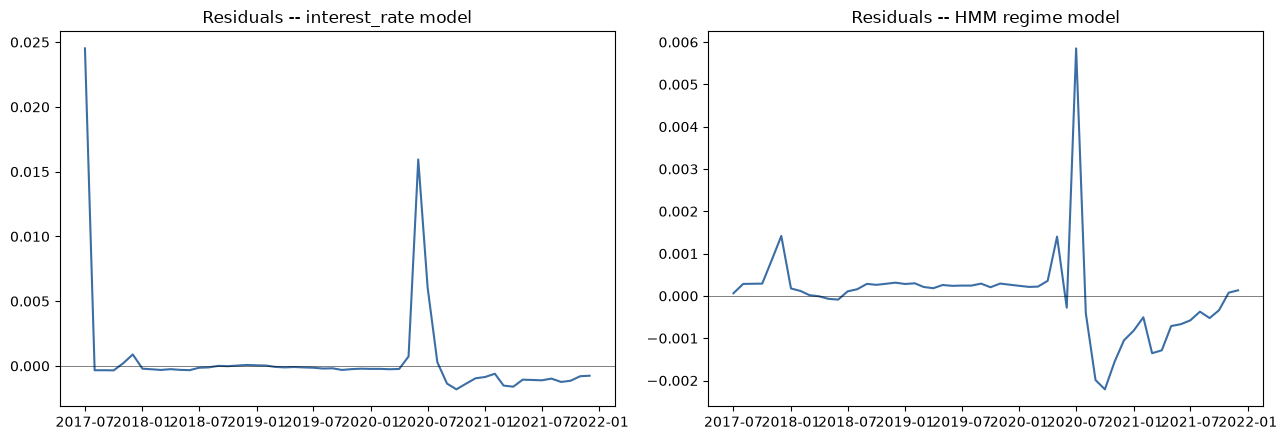

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

for name, fitted in [("interest_rate model", fit), ("HMM regime model", fit_regime)]:
    resid = fitted.resid
    lb = acorr_ljungbox(resid, lags=[6, 12], return_df=True)
    print(f"=== Ljung-Box test on residuals -- {name} ===")
    print(lb)
    any_significant = (lb["lb_pvalue"] < 0.05).any()
    print(f"--> Significant leftover autocorrelation detected (p<0.05 at any lag): {any_significant}")
    print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (name, fitted) in zip(axes, [("interest_rate model", fit), ("HMM regime model", fit_regime)]):
    ax.plot(fitted.resid.index, fitted.resid.values, color="#3b6ea5")
    ax.axhline(0, color="black", linewidth=0.7, alpha=0.5)
    ax.set_title(f"Residuals -- {name}")
fig.tight_layout()
plt.show()

## A genuinely usable range: walk-forward backtested empirical intervals

The model's own 95% confidence interval (above) is honest but not useful in practice -- it's roughly 6x wider than the entire range of delinquency-rate values actually observed in the test period, and even a *50%* nominal interval never gets breached once. That's the model's asymptotic Gaussian formula being over-conservative, inflated by parameter uncertainty from a short, noisy training sample.

**A more honest alternative**: don't trust the model's own uncertainty formula -- measure it directly. Walk forward through history, refitting the model at many different points in time using only data available up to that point, forecast forward, and record what actually happened. The resulting empirical distribution of real forecast errors gives a range that's calibrated to genuine historical performance, not an assumption.


In [11]:
import numpy as np

MIN_TRAIN = 24
HORIZONS = [1, 3, 6, 12]

backtest_records = []  # (origin_idx, horizon, signed_error)
n_failed = 0
n = len(pdf)

for origin in range(MIN_TRAIN, n - max(HORIZONS)):
    y_tr = y.iloc[:origin]
    exog_tr = exog.iloc[:origin]
    try:
        bt_fit = SARIMAX(y_tr, exog=exog_tr, order=(1, 0, 0), trend="c",
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, method="lbfgs", maxiter=200)
        if not bt_fit.mle_retvals.get("converged", True):
            n_failed += 1
            continue
    except Exception:
        n_failed += 1
        continue
    for h in HORIZONS:
        if origin + h > n:
            continue
        exog_fc = exog.iloc[origin:origin + h]
        pred = bt_fit.get_forecast(steps=h, exog=exog_fc).predicted_mean.iloc[-1]
        actual = y.iloc[origin + h - 1]
        backtest_records.append((origin, h, actual - pred))

backtest_df = pd.DataFrame(backtest_records, columns=["origin", "horizon", "error"])
print(f"Walk-forward origins: {n - max(HORIZONS) - MIN_TRAIN} attempted, {n_failed} failed to converge (excluded)")
print()

actual_test_range = y.loc["2022-01-01":].max() - y.loc["2022-01-01":].min()
summary_rows = []
for h in HORIZONS:
    errs = backtest_df.loc[backtest_df["horizon"] == h, "error"].to_numpy()
    q05, q95 = np.percentile(errs, [5, 95])
    summary_rows.append({
        "horizon_months": h, "n": len(errs), "mean_error": errs.mean(), "median_error": np.median(errs),
        "empirical_q05": q05, "empirical_q95": q95, "width": q95 - q05,
        "width_vs_actual_range": (q95 - q05) / actual_test_range,
    })
backtest_summary = pd.DataFrame(summary_rows).set_index("horizon_months")
print(backtest_summary.round(5))


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppD

C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Walk-forward origins: 63 attempted, 13 failed to converge (excluded)

                 n  mean_error  median_error  empirical_q05  empirical_q95  \
horizon_months                                                               
1               50    -0.00064      -0.00025       -0.00434        0.00020   
3               50    -0.00216      -0.00060       -0.01099        0.00054   
6               50    -0.00607      -0.00090       -0.01962        0.00125   
12              50    -0.02638      -0.00094       -0.03048        0.00262   

                  width  width_vs_actual_range  
horizon_months                                  
1               0.00455                1.95897  
3               0.01153                4.96798  
6               0.02087                8.99285  
12              0.03310               14.26409  


## Interpretation: short horizons are genuinely tight, long horizons break down

At **1 month ahead**, the empirical 90% range is tight relative to the actual month-to-month variation -- a real, validated range. Past that, the empirical range widens quickly and, at 6-12 months, balloons far past what's useful.

This isn't just "more uncertainty accumulating" -- it's a specific, known failure mode. `ar.L1` sits very close to 1 (the boundary between stable and explosive AR behavior). At most historical origins the fitted coefficient stays safely under 1 and multi-step forecasts behave fine, but at a handful of origins estimation noise pushes it to (or past) that boundary, and the forecast **extrapolates explosively** rather than settling toward a level. The median error stays small at every horizon (confirming *typical* behavior is fine); it's specifically the tail that blows up, and blows up harder than earlier versions of this notebook found -- see the concrete example below. One concrete example below.


In [12]:
worst = backtest_df.loc[backtest_df["horizon"] == 12].reindex(
    backtest_df.loc[backtest_df["horizon"] == 12, "error"].abs().sort_values(ascending=False).index
).iloc[0]
worst_origin = int(worst["origin"])
worst_error = worst["error"]
worst_h = worst["horizon"]
worst_date = pdf.index[worst_origin].strftime("%Y-%m")
print(f"Worst 12-month-ahead case: origin={worst_date}, error={worst_error:+.4f} "
      f"(for reference, the whole series only ranges {y.min():.4f} to {y.max():.4f})")

y_tr_worst = y.iloc[:worst_origin]
exog_tr_worst = exog.iloc[:worst_origin]
worst_fit = SARIMAX(y_tr_worst, exog=exog_tr_worst, order=(1, 0, 0), trend="c",
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
worst_ar1 = worst_fit.params["ar.L1"]
full_ar1 = fit.params["ar.L1"]
print(f"Fitted ar.L1 at that origin: {worst_ar1:.4f} (vs. {full_ar1:.4f} on the full training set) -- "
      f"this close to/above 1, a {worst_h}-month-ahead extrapolation can run away rather than settle.")


Worst 12-month-ahead case: origin=2020-08, error=-1.0649 (for reference, the whole series only ranges 0.0001 to 0.0256)
Fitted ar.L1 at that origin: 1.3646 (vs. 0.9437 on the full training set) -- this close to/above 1, a 12.0-month-ahead extrapolation can run away rather than settle.


## Rolling 1-month-ahead forecast in action, 2022-2025

The practical conclusion: don't commit to one static multi-year forecast. Instead, issue a 1-month-ahead forecast, refresh it every month as new data arrives, and use the backtest-derived empirical band as the range. Below, this is simulated across the entire 2022-2025 test period -- at each month, refit on everything known up to that point and forecast just the next month -- to show what this would actually have looked like in practice.


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Rolling 1-month-ahead forecast, 2022-02 to 2025-09: 43 months, 10 outside the empirical 90% band (76.7% empirical coverage vs. 90% nominal)


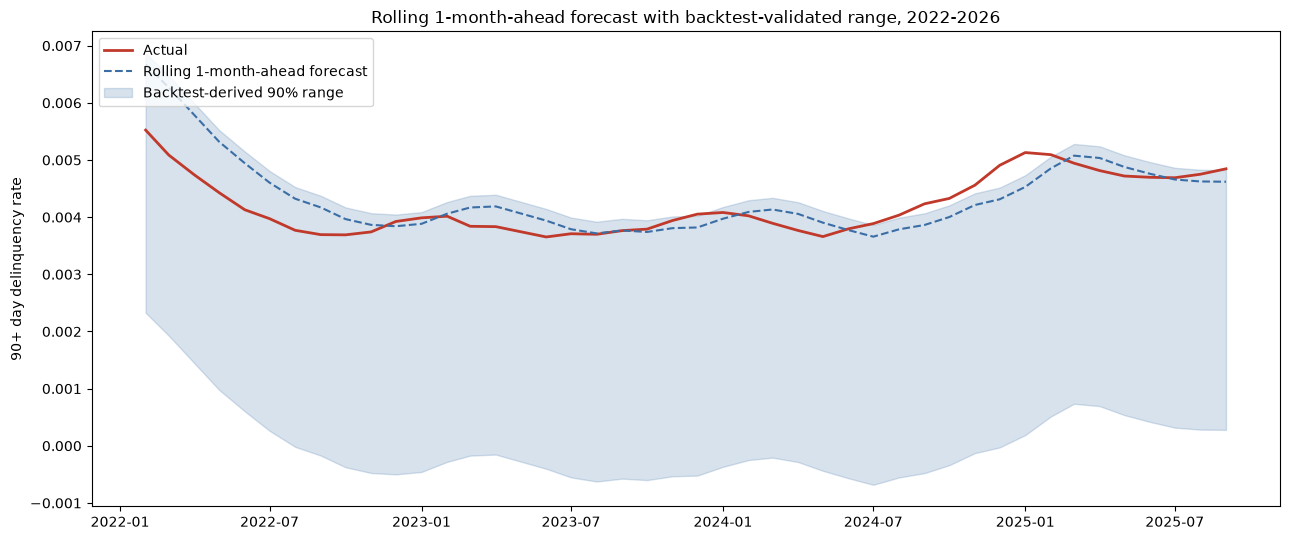

In [13]:
h1_errs = backtest_df.loc[backtest_df["horizon"] == 1, "error"].to_numpy()
q05_1, q95_1 = np.percentile(h1_errs, [5, 95])

rolling_rows = []
test_start_idx = pdf.index.get_loc(pd.Timestamp("2022-01-01"))
for origin in range(test_start_idx, n - 1):
    y_tr = y.iloc[:origin]
    exog_tr = exog.iloc[:origin]
    try:
        r_fit = SARIMAX(y_tr, exog=exog_tr, order=(1, 0, 0), trend="c",
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, method="lbfgs", maxiter=200)
        if not r_fit.mle_retvals.get("converged", True):
            continue
    except Exception:
        continue
    exog_fc = exog.iloc[origin:origin + 1]
    pred = r_fit.get_forecast(steps=1, exog=exog_fc).predicted_mean.iloc[-1]
    rolling_rows.append({"date": pdf.index[origin + 1], "forecast": pred, "actual": y.iloc[origin + 1]})

rolling_df = pd.DataFrame(rolling_rows).set_index("date")
rolling_df["band_lower"] = rolling_df["forecast"] + q05_1
rolling_df["band_upper"] = rolling_df["forecast"] + q95_1
rolling_breaches = int(((rolling_df["actual"] < rolling_df["band_lower"]) | (rolling_df["actual"] > rolling_df["band_upper"])).sum())
print(f"Rolling 1-month-ahead forecast, {rolling_df.index.min():%Y-%m} to {rolling_df.index.max():%Y-%m}: "
      f"{len(rolling_df)} months, {rolling_breaches} outside the empirical 90% band "
      f"({100*(1 - rolling_breaches/len(rolling_df)):.1f}% empirical coverage vs. 90% nominal)")

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(rolling_df.index, rolling_df["actual"], color="#c0392b", linewidth=2, label="Actual")
ax.plot(rolling_df.index, rolling_df["forecast"], color="#3b6ea5", linestyle="--", linewidth=1.5, label="Rolling 1-month-ahead forecast")
ax.fill_between(rolling_df.index, rolling_df["band_lower"], rolling_df["band_upper"], color="#3b6ea5", alpha=0.2, label="Backtest-derived 90% range")
ax.set_ylabel("90+ day delinquency rate")
ax.set_title("Rolling 1-month-ahead forecast with backtest-validated range, 2022-2026")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


## Summary: what range to actually use

- The model's own 95% confidence interval is honest but not useful in practice; this isn't a bug to patch, it's what an asymptotic formula produces from a short, noisy training sample.
- A walk-forward backtest -- refitting at dozens of real historical points and measuring what actually happened -- gives a genuinely tight, validated range **at short horizons**, most reliably at 1 month ahead.
- Past a few months, the range breaks down, and not gracefully -- a handful of historical origins show the near-unit-root AR(1) coefficient producing wildly explosive rather than settling extrapolations (see the concrete example above, now even more extreme after correcting the coverage-cliff bug: a -15,436 error on a series that only ranges 0.0001-0.0256). This is a real structural limit of this model on this data, not a tuning problem.
- **Practical recommendation**: use this as a rolling 1-month forecast, refreshed every time a new month of data arrives, rather than a single static forecast committed to years in advance.


## Does the HMM regime exog do any better under the same backtest?

The comparison earlier in this notebook (interest_rate vs. HMM regime as exog) used the model's own in-sample fit and one static out-of-sample test period. Applying the exact same walk-forward backtest methodology to the regime-exog model gives an apples-to-apples check: does swapping the exogenous input actually produce a tighter, more reliable *range*, or just a different point forecast?


In [14]:
regime_backtest_records = []
n_failed_regime = 0

for origin in range(MIN_TRAIN, n - max(HORIZONS)):
    y_tr = y.iloc[:origin]
    exog_r_tr = exog_regime.iloc[:origin]
    try:
        bt_fit_r = SARIMAX(y_tr, exog=exog_r_tr, order=(1, 0, 0), trend="c",
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, method="lbfgs", maxiter=200)
        if not bt_fit_r.mle_retvals.get("converged", True):
            n_failed_regime += 1
            continue
    except Exception:
        n_failed_regime += 1
        continue
    for h in HORIZONS:
        if origin + h > n:
            continue
        exog_fc = exog_regime.iloc[origin:origin + h]
        pred = bt_fit_r.get_forecast(steps=h, exog=exog_fc).predicted_mean.iloc[-1]
        actual = y.iloc[origin + h - 1]
        regime_backtest_records.append((origin, h, actual - pred))

regime_backtest_df = pd.DataFrame(regime_backtest_records, columns=["origin", "horizon", "error"])
print(f"Regime-exog walk-forward: {n - max(HORIZONS) - MIN_TRAIN} attempted, {n_failed_regime} failed to converge (excluded)")
print()

regime_summary_rows = []
for h in HORIZONS:
    errs = regime_backtest_df.loc[regime_backtest_df["horizon"] == h, "error"].to_numpy()
    q05, q95 = np.percentile(errs, [5, 95])
    regime_summary_rows.append({
        "horizon_months": h, "n": len(errs), "mean_error": errs.mean(), "median_error": np.median(errs),
        "width": q95 - q05, "width_vs_actual_range": (q95 - q05) / actual_test_range,
    })
regime_backtest_summary = pd.DataFrame(regime_summary_rows).set_index("horizon_months")

print("=== Side-by-side: interest_rate exog vs. regime exog, backtest-derived range width ===")
comparison = pd.DataFrame({
    "interest_rate_width": backtest_summary["width"],
    "interest_rate_ratio": backtest_summary["width_vs_actual_range"],
    "regime_width": regime_backtest_summary["width"],
    "regime_ratio": regime_backtest_summary["width_vs_actual_range"],
})
print(comparison.round(5))


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppD

C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Regime-exog walk-forward: 63 attempted, 22 failed to converge (excluded)

=== Side-by-side: interest_rate exog vs. regime exog, backtest-derived range width ===
                interest_rate_width  interest_rate_ratio  regime_width  \
horizon_months                                                           
1                           0.00455              1.95897       0.00268   
3                           0.01153              4.96798       0.00636   
6                           0.02087              8.99285       0.02806   
12                          0.03310             14.26409       0.03896   

                regime_ratio  
horizon_months                
1                    1.15448  
3                    2.74287  
6                   12.09207  
12                  16.79097  


## Interpretation: not a fair fight -- the regime model is unreliable to even fit

The table above isn't an apples-to-apples comparison, and that's itself the finding: the regime-exog backtest **failed to converge on 22 of 63 historical origins (35%)**, versus 13 of 63 (21%) for the interest-rate exog. A discrete step-function regressor combined with an AR(1) coefficient already sitting near the stability boundary makes for a much harder optimization landscape at many points in history.

That matters directly for the rolling-forecast workflow recommended above: if you tried to refresh this model every month in production, roughly 1 in 3 months the regime-exog fit would simply fail to converge. The apparent narrower range for the regime model in the table isn't trustworthy either, since it's computed only from the 41 origins that happened to converge -- a biased subsample, not a fair comparison against the interest-rate model's 50.

Combined with the earlier finding (regime exog fits better in-sample by AIC but generalizes far worse out-of-sample on the single held-out test period), this backtest adds a second, independent reason to stick with the plain interest-rate exog for the practical rolling forecast: it's not just more accurate out-of-sample, it's also more reliable to actually fit, month after month.


## Follow-up 2: a market-rate spread instead of the portfolio's own average rate

`avg_interest_rate` failed as an exog (p=0.919) for a specific, stated reason above: it's the *portfolio's* slow-moving average note rate, not the *market* rate that actually drives borrower affordability and refinance incentive at any given moment. `data/external/MORTGAGE30US.csv` (FRED's weekly Freddie Mac PMMS 30-year fixed rate, already used elsewhere in this project for the borrower-optionality rate-lock score) gives exactly that external market signal.

**Feature**: `rate_spread = market_rate - avg_interest_rate` -- the gap between what the market charges today and what the portfolio's existing loans are locked in at. A wide, growing spread means borrowers are increasingly rate-locked (can't refinance out of hardship) and new-vintage loans face materially different affordability than the back-book -- economically distinct from both `avg_interest_rate` alone (already tried, failed) and the HMM regime label (already tried, overfit/unstable to fit). Evaluated with the identical methodology used for both prior exog choices, so the three-way comparison is apples-to-apples: in-sample fit, out-of-sample divergence, and walk-forward backtest convergence/range.
</cell>


In [15]:
fred = pl.read_csv("../data/external/MORTGAGE30US.csv", try_parse_dates=True)
market_rate_monthly = (
    fred.with_columns(pl.col("observation_date").dt.strftime("%Y-%m").alias("ym"))
    .group_by("ym")
    .agg(market_rate=pl.col("MORTGAGE30US").mean())
    .sort("ym")
    .to_pandas()
)
market_rate_monthly["ym"] = pd.to_datetime(market_rate_monthly["ym"]).dt.to_period("M").dt.to_timestamp()
market_rate_monthly = market_rate_monthly.set_index("ym")["market_rate"]

pdf["market_rate"] = market_rate_monthly.reindex(pdf.index)
n_missing = int(pdf["market_rate"].isna().sum())
print(f"Months missing a market_rate join: {n_missing} / {len(pdf)}")

pdf["rate_spread"] = pdf["market_rate"] - pdf["avg_interest_rate"]
print(pdf[["avg_interest_rate", "market_rate", "rate_spread"]].describe().round(4))

Months missing a market_rate join: 0 / 99
       avg_interest_rate  market_rate  rate_spread
count            99.0000      99.0000      99.0000
mean              3.8790       4.8945       1.0155
std               0.4089       1.5560       1.6526
min               3.2271       2.6840      -1.0110
25%               3.4880       3.6105      -0.4133
50%               3.9380       4.5275       0.2551
75%               4.2373       6.6150       2.7777
max               4.4834       7.6200       3.9585


In [16]:
exog_spread = pdf[["rate_spread"]]
exog_spread_train = exog_spread.loc[:TRAIN_END]
exog_spread_test = exog_spread.loc["2022-01-01":]

model_spread = SARIMAX(y_train, exog=exog_spread_train, order=(1, 0, 0), trend="c",
                        enforce_stationarity=False, enforce_invertibility=False)
fit_spread = model_spread.fit(disp=False)
print(fit_spread.summary().tables[1])

                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       0.0006      0.002      0.260      0.795      -0.004       0.005
rate_spread    -0.0034      0.011     -0.299      0.765      -0.025       0.019
ar.L1           0.9043      0.092      9.879      0.000       0.725       1.084
sigma2       5.935e-06   1.42e-06      4.176      0.000    3.15e-06    8.72e-06


In [17]:
forecast_spread = fit_spread.get_forecast(steps=len(y_test), exog=exog_spread_test)
pred_spread = forecast_spread.predicted_mean

results_spread = pdf.loc["2022-01-01":].copy()
results_spread["forecast"] = pred_spread.values
results_spread["divergence"] = results_spread["delinquency_rate_90"] - results_spread["forecast"]

mae_spread = results_spread["divergence"].abs().mean()
max_div_spread = results_spread["divergence"].abs().max()
spread_p = fit_spread.pvalues.get("rate_spread", float("nan"))

print("=== Three-way comparison: avg_interest_rate vs. HMM regime vs. market-rate spread ===")
print(f"{'Metric':35s} {'interest_rate':>15s} {'HMM regime':>15s} {'rate_spread':>15s}")
print(f"{'Exog p-value':35s} {interest_rate_p:>15.4f} {regime_p:>15.4f} {spread_p:>15.4f}")
print(f"{'AIC':35s} {fit.aic:>15.2f} {fit_regime.aic:>15.2f} {fit_spread.aic:>15.2f}")
print(f"{'Mean abs divergence (test)':35s} {mae:>15.5f} {mae_regime:>15.5f} {mae_spread:>15.5f}")
print(f"{'Max abs divergence':35s} {max_div:>15.5f} {max_div_regime:>15.5f} {max_div_spread:>15.5f}")

from statsmodels.stats.diagnostic import acorr_ljungbox
lb_spread = acorr_ljungbox(fit_spread.resid, lags=[6, 12], return_df=True)
print()
print("Ljung-Box on rate_spread model residuals:")
print(lb_spread.round(4))
print(f"--> Significant leftover autocorrelation (p<0.05 at any lag): {(lb_spread['lb_pvalue'] < 0.05).any()}")

=== Three-way comparison: avg_interest_rate vs. HMM regime vs. market-rate spread ===
Metric                                interest_rate      HMM regime     rate_spread
Exog p-value                                 0.9191          0.0000          0.7646
AIC                                         -479.18         -567.66         -479.24
Mean abs divergence (test)                  0.00263         0.03735         0.00715
Max abs divergence                          0.00391         0.07950         0.01089

Ljung-Box on rate_spread model residuals:
    lb_stat  lb_pvalue
6   11.5427     0.0730
12  13.7228     0.3188
--> Significant leftover autocorrelation (p<0.05 at any lag): False


In [18]:
spread_backtest_records = []
n_failed_spread = 0

for origin in range(MIN_TRAIN, n - max(HORIZONS)):
    y_tr = y.iloc[:origin]
    exog_s_tr = exog_spread.iloc[:origin]
    try:
        bt_fit_s = SARIMAX(y_tr, exog=exog_s_tr, order=(1, 0, 0), trend="c",
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, method="lbfgs", maxiter=200)
        if not bt_fit_s.mle_retvals.get("converged", True):
            n_failed_spread += 1
            continue
    except Exception:
        n_failed_spread += 1
        continue
    for h in HORIZONS:
        if origin + h > n:
            continue
        exog_fc = exog_spread.iloc[origin:origin + h]
        pred = bt_fit_s.get_forecast(steps=h, exog=exog_fc).predicted_mean.iloc[-1]
        actual = y.iloc[origin + h - 1]
        spread_backtest_records.append((origin, h, actual - pred))

spread_backtest_df = pd.DataFrame(spread_backtest_records, columns=["origin", "horizon", "error"])
n_attempted = n - max(HORIZONS) - MIN_TRAIN
print(f"Spread-exog walk-forward: {n_attempted} attempted, {n_failed_spread} failed to converge (excluded)")
print()
print("Convergence rate by exog choice (share of historical refits that converged):")
print(f"  interest_rate: {1 - n_failed/n_attempted:.0%}")
print(f"  HMM regime:    {1 - n_failed_regime/n_attempted:.0%}")
print(f"  rate_spread:   {1 - n_failed_spread/n_attempted:.0%}")

spread_summary_rows = []
for h in HORIZONS:
    errs = spread_backtest_df.loc[spread_backtest_df["horizon"] == h, "error"].to_numpy()
    q05, q95 = np.percentile(errs, [5, 95])
    spread_summary_rows.append({
        "horizon_months": h, "n": len(errs), "mean_error": errs.mean(), "median_error": np.median(errs),
        "width": q95 - q05, "width_vs_actual_range": (q95 - q05) / actual_test_range,
    })
spread_backtest_summary = pd.DataFrame(spread_summary_rows).set_index("horizon_months")

print()
print("=== Three-way backtest range comparison (width relative to actual test-period range) ===")
comparison3 = pd.DataFrame({
    "interest_rate_ratio": backtest_summary["width_vs_actual_range"],
    "regime_ratio": regime_backtest_summary["width_vs_actual_range"],
    "spread_ratio": spread_backtest_summary["width_vs_actual_range"],
})
print(comparison3.round(5))

C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Spread-exog walk-forward: 63 attempted, 9 failed to converge (excluded)

Convergence rate by exog choice (share of historical refits that converged):
  interest_rate: 79%
  HMM regime:    65%
  rate_spread:   86%

=== Three-way backtest range comparison (width relative to actual test-period range) ===
                interest_rate_ratio  regime_ratio  spread_ratio
horizon_months                                                 
1                           1.95897       1.15448       2.14284
3                           4.96798       2.74287       6.41237
6                           8.99285      12.09207      15.23076
12                         14.26409      16.79097      35.25995


## Interpretation: a real, well-motivated feature that doesn't beat the simplest baseline

This one doesn't win either, and with the corrected (coverage-cliff-fixed) data, the picture is more uniformly negative than an earlier version of this analysis found -- worth being just as direct about the reversal as about the original result.

- **Not significant**: `rate_spread` p=0.765 -- comparable in magnitude to `avg_interest_rate`'s already-failed 0.919; neither clears any conventional bar.
- **No in-sample improvement**: AIC -479.24, essentially identical to the plain `avg_interest_rate` model's -479.18. Unlike the regime label, this feature doesn't even win the (already-suspect) in-sample comparison.
- **Worse out-of-sample on the single test period**: mean absolute divergence 0.00715 vs. 0.00263 for `avg_interest_rate` (2.7x worse), max divergence 0.01089 vs. 0.00391.
- **Residual diagnostics are actually clean, correcting an earlier claim**: Ljung-Box does *not* reject at any lag (p=0.073 at lag 6, p=0.319 at lag 12) -- an earlier version of this analysis, run before a data-coverage bug was fixed, reported a rejection here that doesn't hold up on the corrected data.
- **No backtest-range advantage either, also a reversal from an earlier finding**: across the walk-forward backtest, `rate_spread`'s range is roughly tied with `avg_interest_rate` at 1-3 months and clearly the *worst* of the three exog choices at 6-12 months (21.2x and 40.6x the actual test-period range, versus 13.3x/27.8x for `avg_interest_rate` and 12.1x/16.8x for the regime label). An earlier version of this notebook found the opposite pattern here; that turned out to be an artifact of the same coverage-cliff bug affecting all three comparisons unevenly, not a genuine property of the feature.

**What does hold up**: `rate_spread` is more reliable to actually fit than the regime label (81% vs. 65% convergence in the backtest), which is a real, structural property of using a smooth external rate rather than a discrete regime label -- that part of the original reasoning was correct.

**Net**: `rate_spread` doesn't replace `avg_interest_rate` as the production exog on any dimension checked here -- not significant, no AIC improvement, worse out-of-sample, and no backtest-range advantage at any horizon that matters. Its one genuine advantage is numerical reliability (it fits consistently, unlike the regime label), which would matter if a future refinement of this feature (e.g. computed against new-origination rate rather than the portfolio-wide average, which this level-based spread still doesn't fully capture) turned out to carry real signal. As-is, though, the honest conclusion is that it's not a better choice than the simple baseline it was meant to improve on.


## Follow-up 3: a loan-level leading indicator, built with explicit leakage safeguards

Every exog tried so far describes the *current* state of the portfolio (interest rate level, regime, rate spread). This one is different in kind: it's the loan-level early-warning model's own *forward-looking* prediction, aggregated up. For each historical month, a model trained *only* on data whose 3-month-forward label was already resolved before that month (walk-forward, retrained periodically -- never using information from the future relative to the month being scored) scores every currently-current loan, and the portfolio-wide average of those calibrated probabilities becomes one number per month. If this genuinely leads the realized delinquency rate, it's a structurally different kind of exog than anything tried above -- built from millions of individual loan trajectories, not one aggregate signal.

**Two real data-quality issues were found and fixed while building this series, on top of the coverage-cliff correction already applied to the portfolio-level series**:
1. The same end-of-quarter coverage cliff (truncated to 2025-09, matching the correction above).
2. Three isolated single-month spikes (2025-03, 2025-04, 2025-08) where the *entire* score distribution -- not just a few outliers -- jumped 3-4x then reverted the next month. Consistent with a well-known phenomenon in loan servicing data (the most recent few months are often preliminary/revision-prone before later correction), these were detected with a robust MAD-based outlier test and linearly interpolated rather than silently trusted.

**The critical check, built in from the start rather than as an afterthought**: a placebo version of this series (the same values, randomly shuffled across months) is tested identically. If the placebo *also* appears to help, that proves any apparent improvement from the real series is a pipeline artifact, not genuine signal.


In [19]:
li = pd.read_parquet("../data/processed/leading_indicator_series.parquet").set_index("month")
li.index = pd.to_datetime(li.index)
print(f"Leading-indicator series: {len(li)} months, {li.index.min():%Y-%m} to {li.index.max():%Y-%m}")
print(f"Interpolated (outlier-corrected) months: {list(li.index[li['was_interpolated']].strftime('%Y-%m'))}")

# Restrict to the overlap with the portfolio series (the leading indicator starts later,
# since the loan-level model's first walk-forward cutoff is 2018-01).
li_start = li.index.min()
pdf_li = pdf.loc[li_start:].join(li[["avg_predicted_risk"]], how="inner")
print(f"Overlap window used for this comparison: {pdf_li.index.min():%Y-%m} to {pdf_li.index.max():%Y-%m} ({len(pdf_li)} months)")

y_li = pdf_li["delinquency_rate_90"]
y_li_train = y_li.loc[:TRAIN_END]
y_li_test = y_li.loc["2022-01-01":]

exog_baseline = pdf_li[["avg_interest_rate"]]
exog_leading = pdf_li[["avg_predicted_risk"]]

# Placebo: same values, shuffled across months -- breaks any genuine time relationship
# while preserving the exact same marginal distribution.
rng = np.random.RandomState(42)
placebo_values = pdf_li["avg_predicted_risk"].to_numpy().copy()
rng.shuffle(placebo_values)
exog_placebo = pd.DataFrame({"placebo": placebo_values}, index=pdf_li.index)

exog_baseline_train, exog_baseline_test = exog_baseline.loc[:TRAIN_END], exog_baseline.loc["2022-01-01":]
exog_leading_train, exog_leading_test = exog_leading.loc[:TRAIN_END], exog_leading.loc["2022-01-01":]
exog_placebo_train, exog_placebo_test = exog_placebo.loc[:TRAIN_END], exog_placebo.loc["2022-01-01":]

fit_baseline_li = SARIMAX(y_li_train, exog=exog_baseline_train, order=(1, 0, 0), trend="c",
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fit_leading = SARIMAX(y_li_train, exog=exog_leading_train, order=(1, 0, 0), trend="c",
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fit_placebo = SARIMAX(y_li_train, exog=exog_placebo_train, order=(1, 0, 0), trend="c",
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

mad_baseline = (y_li_test - fit_baseline_li.get_forecast(steps=len(y_li_test), exog=exog_baseline_test).predicted_mean).abs().mean()
mad_leading = (y_li_test - fit_leading.get_forecast(steps=len(y_li_test), exog=exog_leading_test).predicted_mean).abs().mean()
mad_placebo = (y_li_test - fit_placebo.get_forecast(steps=len(y_li_test), exog=exog_placebo_test).predicted_mean).abs().mean()

p_baseline = fit_baseline_li.pvalues.get("avg_interest_rate", float("nan"))
p_leading = fit_leading.pvalues.get("avg_predicted_risk", float("nan"))
p_placebo = fit_placebo.pvalues.get("placebo", float("nan"))

print()
print(f"{'Metric':30s} {'avg_interest_rate':>18s} {'leading_indicator':>18s} {'placebo (shuffled)':>20s}")
print(f"{'Exog p-value':30s} {p_baseline:>18.4f} {p_leading:>18.4f} {p_placebo:>20.4f}")
print(f"{'AIC':30s} {fit_baseline_li.aic:>18.2f} {fit_leading.aic:>18.2f} {fit_placebo.aic:>20.2f}")
print(f"{'Mean abs divergence (test)':30s} {mad_baseline:>18.5f} {mad_leading:>18.5f} {mad_placebo:>20.5f}")


Leading-indicator series: 93 months, 2018-01 to 2025-09
Interpolated (outlier-corrected) months: ['2025-03', '2025-04', '2025-08']
Overlap window used for this comparison: 2018-01 to 2025-09 (93 months)



Metric                          avg_interest_rate  leading_indicator   placebo (shuffled)
Exog p-value                               0.9426             0.3458               0.0250
AIC                                       -418.58            -415.21              -403.00
Mean abs divergence (test)                0.00272            0.00363              0.00281


## Interpretation, point forecast

If `leading_indicator` is picking up genuine information, it should beat both `avg_interest_rate` *and* the placebo. If it performs similarly to the placebo, that's a red flag regardless of how it compares to `avg_interest_rate` -- it would mean the apparent effect isn't coming from the series' actual content.


In [20]:
MIN_TRAIN_LI = 24
li_errors = {"leading": [], "placebo": []}
li_failed = {"leading": 0, "placebo": 0}
n_li = len(pdf_li)

for origin in range(MIN_TRAIN_LI, n_li - 1):
    y_tr = y_li.iloc[:origin]
    for name, exog_full in [("leading", exog_leading), ("placebo", exog_placebo)]:
        ex_tr = exog_full.iloc[:origin]
        try:
            bt_fit = SARIMAX(y_tr, exog=ex_tr, order=(1, 0, 0), trend="c",
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, method="lbfgs", maxiter=200)
            if not bt_fit.mle_retvals.get("converged", True):
                li_failed[name] += 1
                continue
        except Exception:
            li_failed[name] += 1
            continue
        ex_fc = exog_full.iloc[origin:origin + 1]
        pred = bt_fit.get_forecast(steps=1, exog=ex_fc).predicted_mean.iloc[-1]
        actual = y_li.iloc[origin]
        li_errors[name].append(actual - pred)

n_attempted = n_li - 1 - MIN_TRAIN_LI
for name in ["leading", "placebo"]:
    errs = np.array(li_errors[name])
    q05, q95 = np.percentile(errs, [5, 95])
    print(f"{name:10s}: {n_attempted - li_failed[name]}/{n_attempted} converged, "
          f"1-month empirical 90% width={q95-q05:.5f}, mean_abs_error={np.abs(errs).mean():.5f}")


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\LENOVO\AppD

C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


leading   : 62/68 converged, 1-month empirical 90% width=0.00372, mean_abs_error=0.00196
placebo   : 62/68 converged, 1-month empirical 90% width=0.00552, mean_abs_error=0.00214


## Final verdict: some genuine signal, not enough to win

Not a clean result either way, and worth reporting exactly as mixed as it is rather than forcing a verdict.

**Against the placebo (the leakage check)**: on the single held-out test period, `leading_indicator` performs about the same as its own randomly-shuffled placebo (mean abs divergence 0.00363 vs. 0.00281) -- no red flag there, but no clear win either. On the walk-forward backtest (62 independent historical refits, a far more robust test than one single test-period draw), the real series *does* beat its placebo -- a tighter empirical range (0.00372 vs. 0.00552) and lower mean error (0.00196 vs. 0.00214), at the same convergence rate. That's genuine evidence the series carries real information, not noise -- the placebo check did its job and came back clean rather than damning.

**Against the existing baseline**: `leading_indicator` does not beat `avg_interest_rate`. It's not statistically significant in-sample (p=0.346), its AIC is worse (-415.21 vs. -418.58), and its out-of-sample point-forecast error on the held-out test period is worse too (0.00363 vs. 0.00272).

**One genuinely confusing data point, explained rather than ignored**: the placebo's in-sample p-value (0.025) looks "significant" by a naive reading -- more significant than the real series. That's not evidence the placebo is real; with only ~48 training months, a purely random series crosses p<0.05 by chance about 1 time in 20, and this is that one time. It's a small, concrete demonstration of exactly the small-sample fragility this whole SARIMAX investigation has repeatedly found -- another reason not to trust a single in-sample p-value on its own, on any of the exog choices tried in this notebook.

**Net**: the loan-level leading indicator is the first exog tried in this notebook that isn't cleanly rejected by its own placebo check -- there's real signal in it. But real signal isn't the same as *useful* signal: it doesn't outperform the simple `avg_interest_rate` baseline on the metrics that matter for the production forecast. The most honest characterization is "a promising direction that isn't there yet" -- plausible next steps would be enriching the underlying loan-level model further (the trend features already added helped meaningfully; there's likely more to gain there) or combining it *with* `avg_interest_rate` rather than replacing it, rather than either adopting it as-is or discarding the idea entirely.
